- Explore data
- Visualize patterns
- Find problems (missing values, outliers)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

Structure of data

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


summary statistics

In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


array([[<Axes: title={'center': 'person_age'}>,
        <Axes: title={'center': 'person_income'}>,
        <Axes: title={'center': 'person_emp_length'}>],
       [<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'loan_int_rate'}>,
        <Axes: title={'center': 'loan_status'}>],
       [<Axes: title={'center': 'loan_percent_income'}>,
        <Axes: title={'center': 'cb_person_cred_hist_length'}>, <Axes: >]],
      dtype=object)

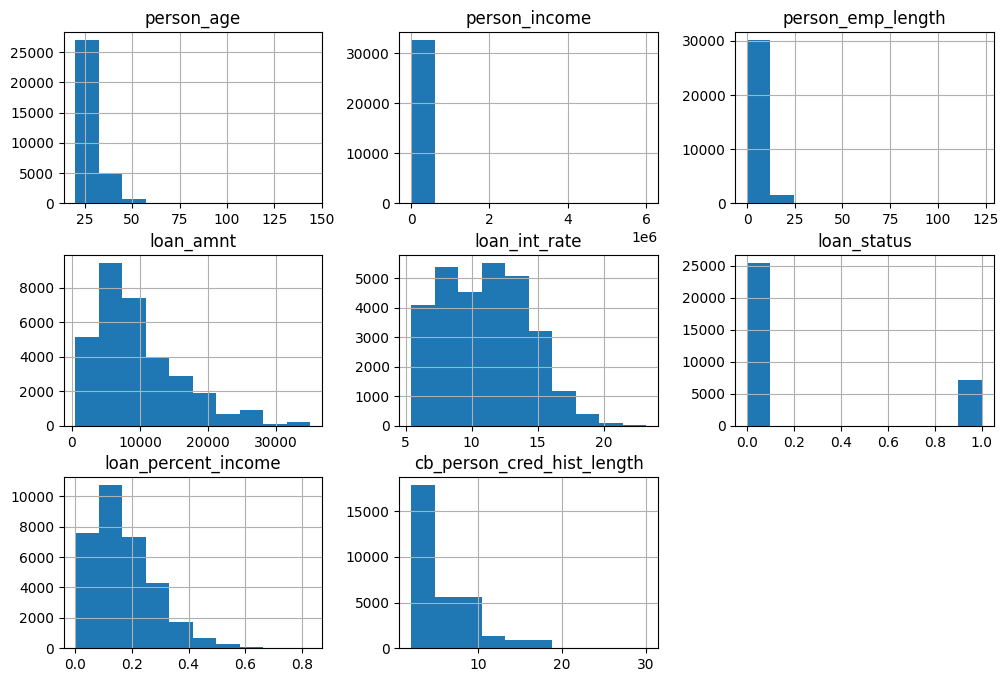

In [8]:
df.hist(figsize=(12,8))

In [2]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

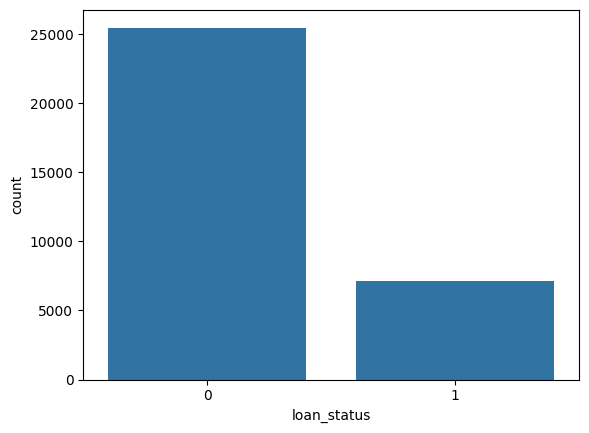

In [3]:
sns.countplot(x='loan_status', data=df)
plt.show()

Explore Category Features

In [5]:
df['person_home_ownership'].value_counts()

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

In [6]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [7]:
df['loan_grade'].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [8]:
df['cb_person_default_on_file'].value_counts()

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

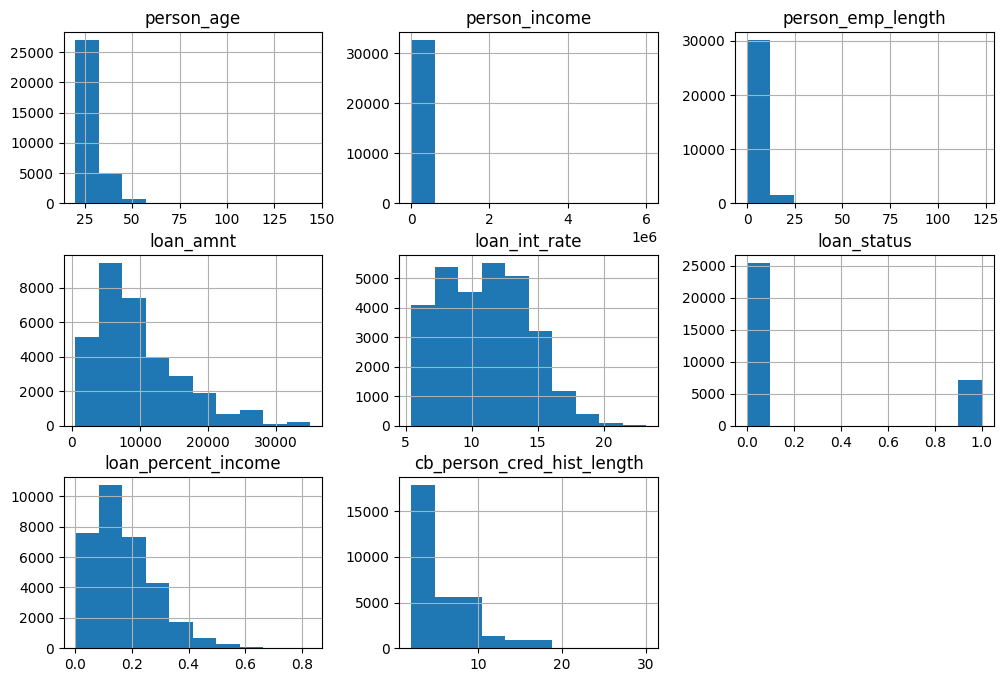

In [9]:
df.hist(figsize=(12,8))
plt.show()

Income vs Default

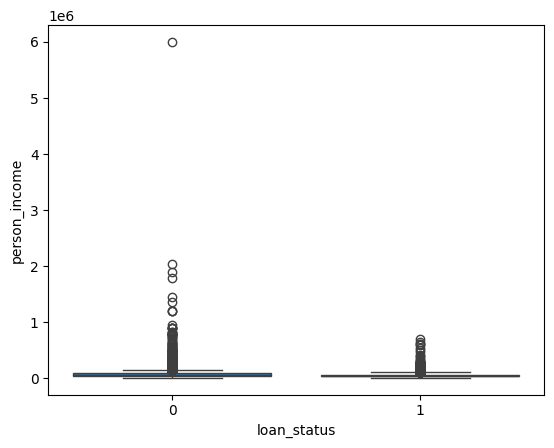

In [10]:
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.show()

Loan % Income vs Default

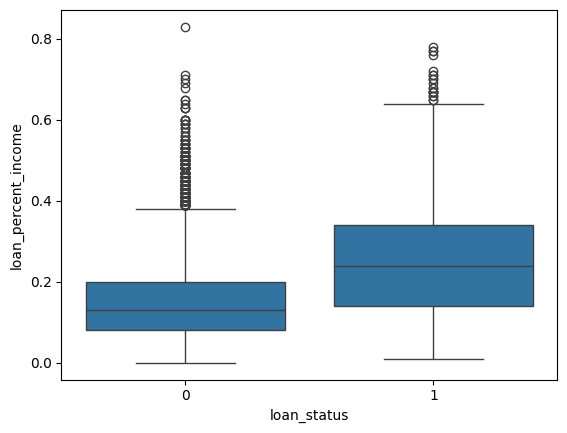

In [11]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.show()

Employment Length vs Default

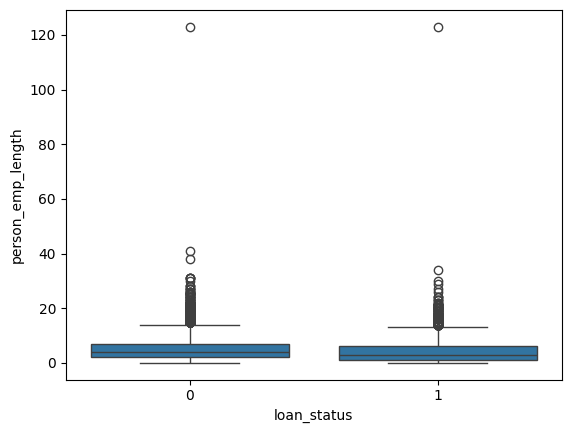

In [12]:
sns.boxplot(x='loan_status', y='person_emp_length', data=df)
plt.show()

Correlation Heatmap

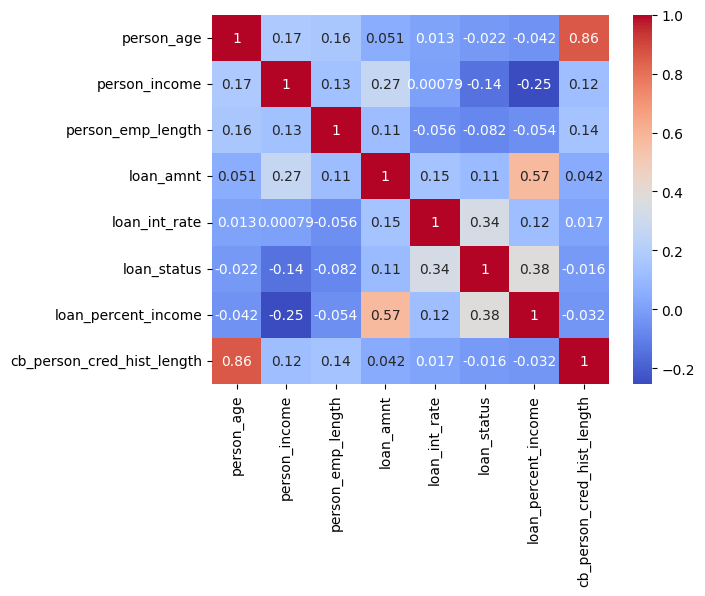

In [13]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

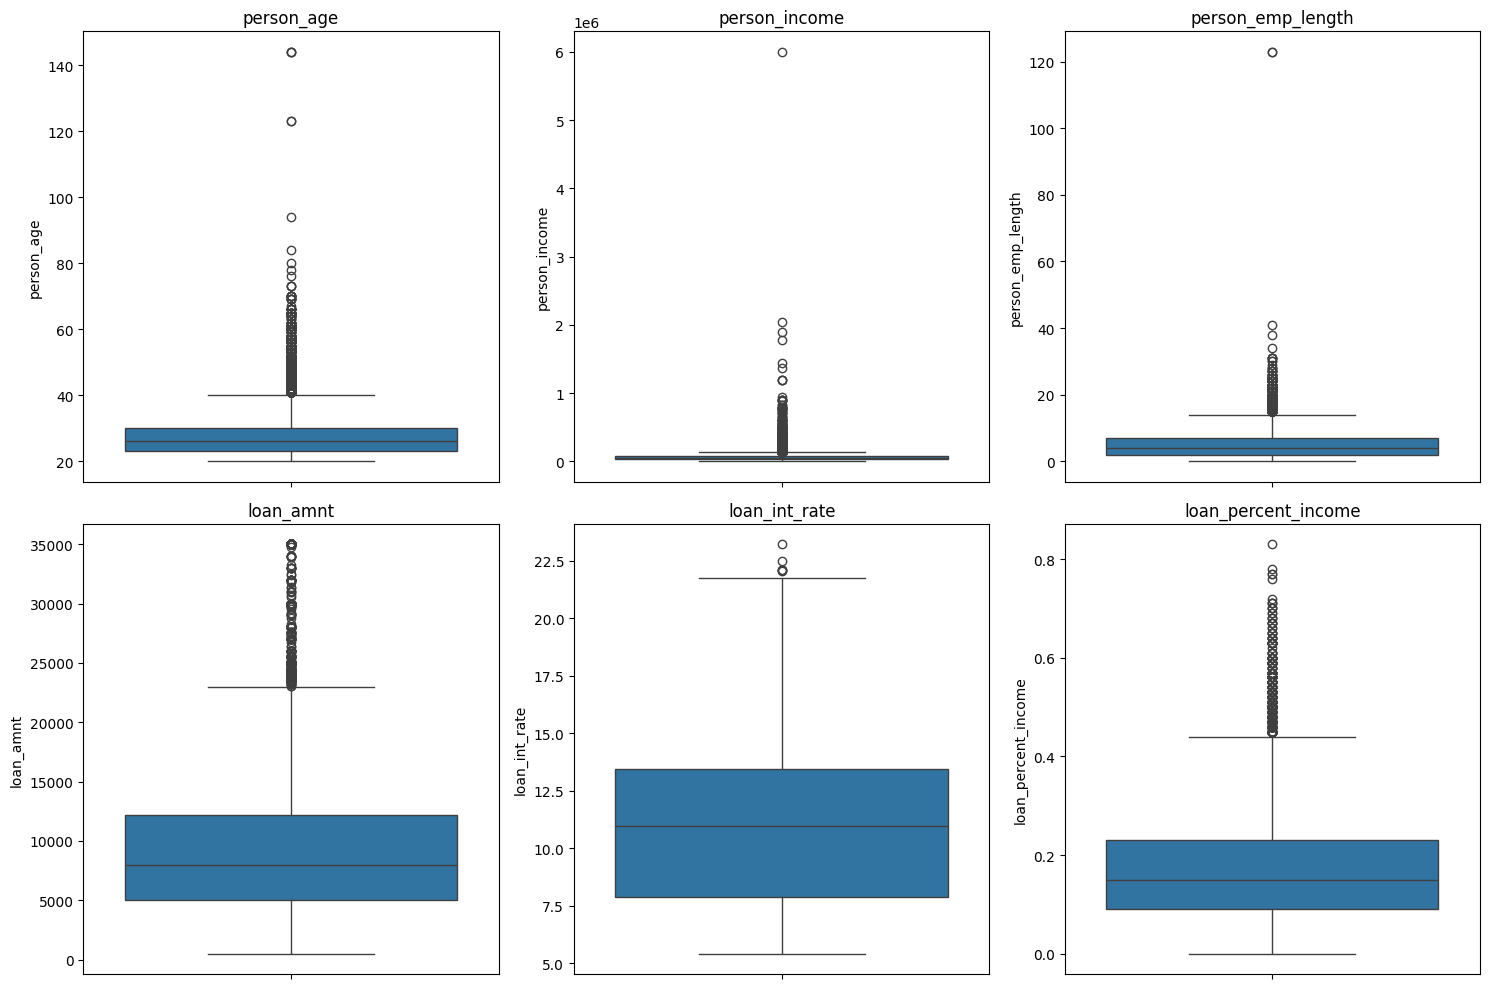

In [14]:
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income'
]

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
def detect_outliers_detail(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    lower_outliers = df[df[col] < lower].shape[0]
    upper_outliers = df[df[col] > upper].shape[0]
    
    total_outliers = lower_outliers + upper_outliers
    
    print(f"{col} outliers: {total_outliers}")
    print(f"  upper bound: {round(upper, 2)}    outlier: {upper_outliers}")
    print(f"  lower bound: {round(lower, 2)}    outlier: {lower_outliers}")
    print()

# Run for all numerical columns
for col in num_cols:
    detect_outliers_detail(col)

person_age outliers: 1494
  upper bound: 40.5    outlier: 1494
  lower bound: 12.5    outlier: 0

person_income outliers: 1484
  upper bound: 140250.0    outlier: 1484
  lower bound: -22550.0    outlier: 0

person_emp_length outliers: 853
  upper bound: 14.5    outlier: 853
  lower bound: -5.5    outlier: 0

loan_amnt outliers: 1689
  upper bound: 23000.0    outlier: 1689
  lower bound: -5800.0    outlier: 0

loan_int_rate outliers: 6
  upper bound: 21.83    outlier: 6
  lower bound: -0.46    outlier: 0

loan_percent_income outliers: 651
  upper bound: 0.44    outlier: 651
  lower bound: -0.12    outlier: 0



Compare person_age and person_emp_length

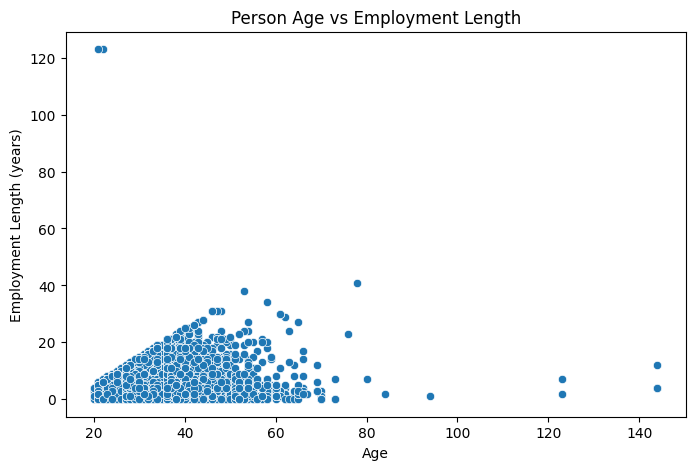

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='person_age', y='person_emp_length', data=df)

plt.title("Person Age vs Employment Length")
plt.xlabel("Age")
plt.ylabel("Employment Length (years)")
plt.show()

duplicate row

In [3]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 165


In [ ]:
pd.set_option('display.max_rows', None)

dup = df[df.duplicated(keep=False)]
dup = dup.sort_values(by=df.columns.tolist())

dup

In [14]:
print((df['person_age'] > 65).sum())

35


In [15]:
print((df['person_age'] < 18).sum())

0


In [17]:
(df['person_age'] - df['person_emp_length'] < 15).sum()

np.int64(2)

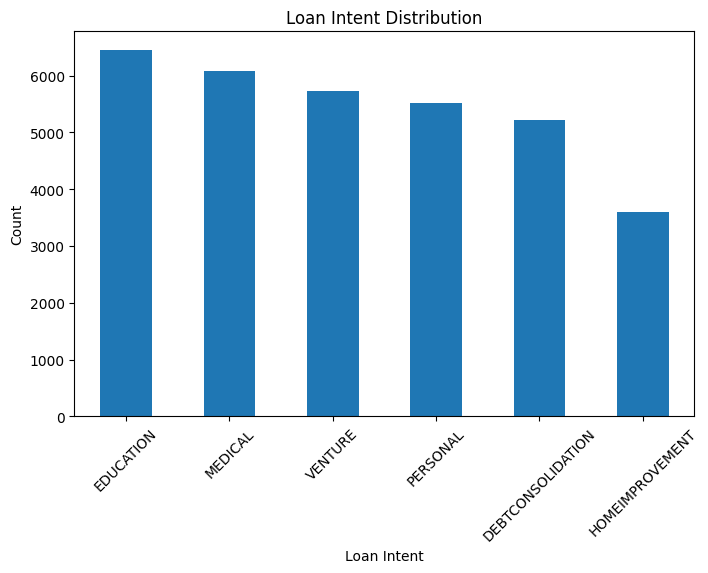

In [18]:
df['loan_intent'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title('Loan Intent Distribution')
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()